# Task 1: Simulation and Sensitivity Analysis of Chaotic Systems

<div align="center">
<strong>Omar Gamal ElKady</strong><br>
Nile University
</div>

In [1]:
from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 110,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
        "lines.linewidth": 0.9,
    }
)


def rk4(rhs, y0, dt, total_time, parameters):
    """Fixed-step classical RK4 integrator."""
    steps = int(round(total_time / dt))
    t = np.linspace(0.0, steps * dt, steps + 1)
    y = np.empty((steps + 1, len(y0)), dtype=float)
    y[0] = np.asarray(y0, dtype=float)
    for i in range(steps):
        state = y[i]
        k1 = np.asarray(rhs(state, parameters))
        k2 = np.asarray(rhs(state + 0.5 * dt * k1, parameters))
        k3 = np.asarray(rhs(state + 0.5 * dt * k2, parameters))
        k4 = np.asarray(rhs(state + dt * k3, parameters))
        y[i + 1] = state + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    return t, y

## Part A — Discrete Chaotic Systems

A discrete system updates one step, or iteration, at a time: $\mathbf{x}_{n+1}=f(\mathbf{x}_n)$. The **state variables** are its current values, while **control parameters** are fixed settings that can make the result steady, repeating, or chaotic.

### A.1 Logistic map

$$x_{n+1}=r x_n(1-x_n)$$

| Setting | Value |
|---|---|
| State | $x \in [0,1]$ |
| Control parameter | $r=3.9$ for the representative chaotic time series |
| Initial condition | $x_0=0.5$ |
| Iterations | 1000; the first 300 are treated as transient |

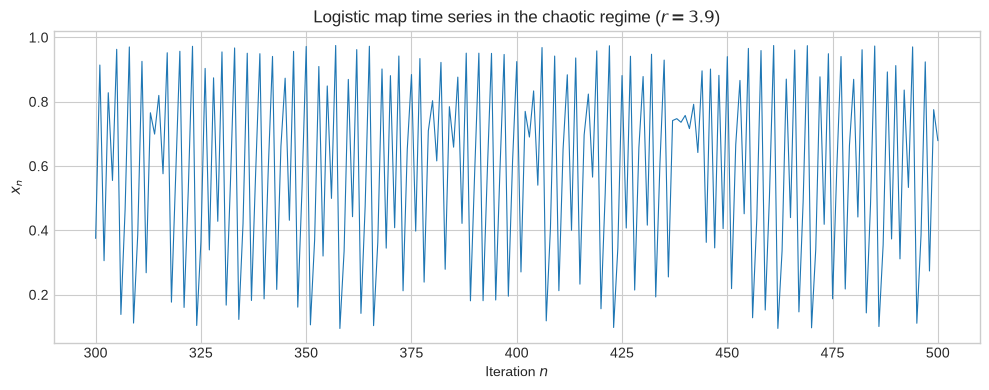

In [2]:
def logistic_map(r, x0=0.5, iterations=1000):
    x = np.empty(iterations + 1)
    x[0] = x0
    for n in range(iterations):
        x[n + 1] = r * x[n] * (1.0 - x[n])
    return x


x_logistic = logistic_map(r=3.9, x0=0.5, iterations=1000)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(300, 501), x_logistic[300:501], color="tab:blue", lw=0.8)
ax.set(title="Logistic map time series in the chaotic regime ($r=3.9$)", xlabel="Iteration $n$", ylabel="$x_n$")
fig.tight_layout()
plt.show()

At $r=3.9$, the values stay between 0 and 1 but never settle or repeat in a simple pattern. This is deterministic chaos: a fixed rule produces an irregular result.

### A.2 Hénon map

$$x_{n+1}=1-a x_n^2+y_n, \qquad y_{n+1}=b x_n$$

| Setting | Value |
|---|---|
| States | $(x,y)$ |
| Control parameters | $a=1.4$, $b=0.3$ |
| Initial condition | $(x_0,y_0)=(0,0)$ |
| Iterations | 5000; discard the first 500 |

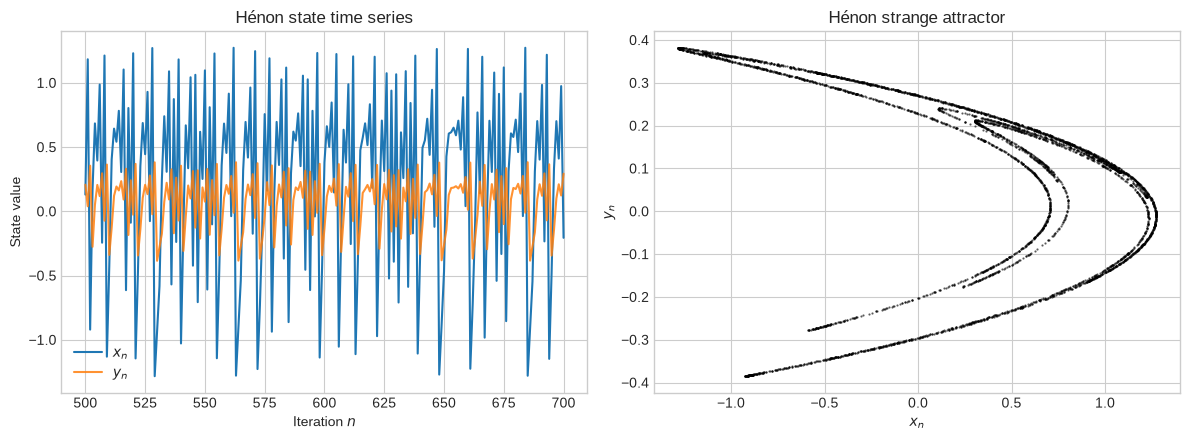

In [3]:
def henon_map(a=1.4, b=0.3, x0=0.0, y0=0.0, iterations=5000):
    states = np.empty((iterations + 1, 2))
    states[0] = (x0, y0)
    for n in range(iterations):
        x, y = states[n]
        states[n + 1] = (1.0 - a * x * x + y, b * x)
    return states


henon = henon_map()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
n_view = np.arange(500, 701)
axes[0].plot(n_view, henon[500:701, 0], label="$x_n$")
axes[0].plot(n_view, henon[500:701, 1], label="$y_n$", alpha=0.85)
axes[0].set(title="Hénon state time series", xlabel="Iteration $n$", ylabel="State value")
axes[0].legend()
axes[1].scatter(henon[500:, 0], henon[500:, 1], s=0.35, color="black", alpha=0.6, rasterized=True)
axes[1].set(title="Hénon strange attractor", xlabel="$x_n$", ylabel="$y_n$")
fig.tight_layout()
plt.show()

The values change irregularly, but the plotted points form a thin folded shape called a strange attractor. Its repeated bands suggest a fractal pattern, where similar detail appears at smaller scales.

### A.3 Bifurcation diagrams

For each parameter value, the early startup values (the transient) are skipped. The later values are plotted to show the system's long-term behavior.

| System | Parameter sweep | Initial state | Iterations per value |
|---|---|---|---|
| Logistic | $r \in [2.5,4.0]$, $\Delta r=0.002$ | $x_0=0.5$ | 700 transient + 200 retained |
| Hénon | $a \in [1.0,1.4]$, $\Delta a=0.002$; $b=0.3$ | $(0,0)$ | 1000 transient + 250 retained |

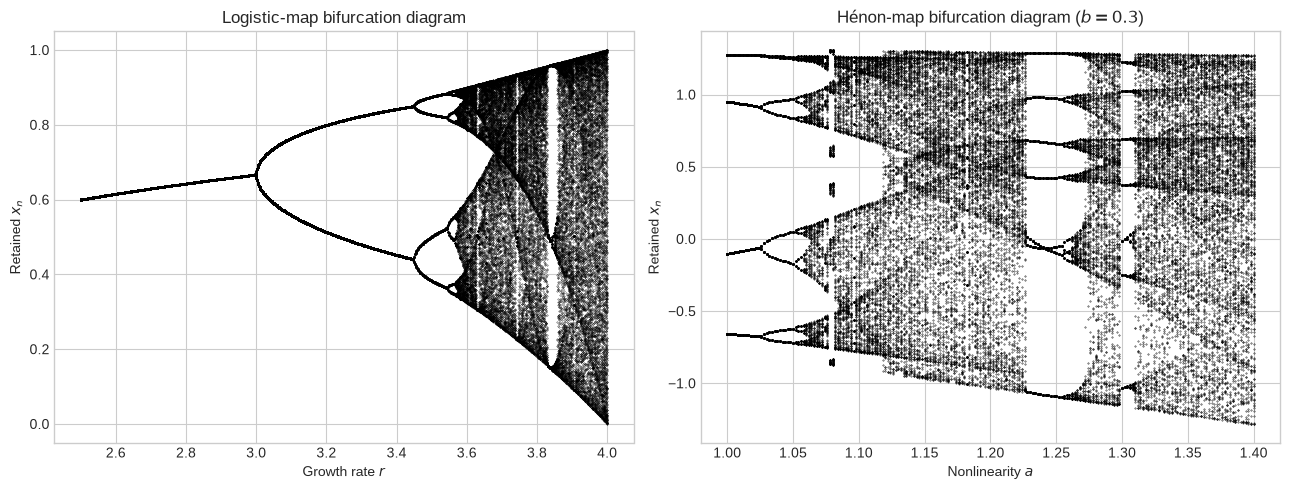

In [4]:
def logistic_bifurcation(r_values, x0=0.5, transient=700, retained=200):
    x = np.full(r_values.shape, x0, dtype=float)
    for _ in range(transient):
        x = r_values * x * (1.0 - x)
    samples = np.empty((retained, len(r_values)))
    for i in range(retained):
        x = r_values * x * (1.0 - x)
        samples[i] = x
    return samples


def henon_bifurcation(a_values, b=0.3, transient=1000, retained=250):
    x = np.zeros_like(a_values)
    y = np.zeros_like(a_values)
    for _ in range(transient):
        x, y = 1.0 - a_values * x * x + y, b * x
    samples = np.empty((retained, len(a_values)))
    for i in range(retained):
        x, y = 1.0 - a_values * x * x + y, b * x
        samples[i] = x
    return samples


r_values = np.arange(2.5, 4.0001, 0.002)
a_values = np.arange(1.0, 1.4001, 0.002)
logistic_samples = logistic_bifurcation(r_values)
henon_samples = henon_bifurcation(a_values)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(np.tile(r_values, logistic_samples.shape[0]), logistic_samples.ravel(), s=0.06, color="black", rasterized=True)
axes[0].set(title="Logistic-map bifurcation diagram", xlabel="Growth rate $r$", ylabel="Retained $x_n$")
axes[1].scatter(np.tile(a_values, henon_samples.shape[0]), henon_samples.ravel(), s=0.1, color="black", rasterized=True)
axes[1].set(title="Hénon-map bifurcation diagram ($b=0.3$)", xlabel="Nonlinearity $a$", ylabel="Retained $x_n$")
fig.tight_layout()
plt.show()

**Observation.** The logistic branches split from one to two, then four, before becoming chaotic; this is called period doubling. The Hénon map shows similar splitting and irregular bands as $a$ increases.

## Part B — Continuous Chaotic Systems

**Phase space** is a plot with one axis for each state variable, and its line shows how the system changes. A Lyapunov exponent measures how quickly nearby paths separate: chaos has one positive exponent, while hyperchaos has at least two.

### B.1 Lorenz system

$$\dot{x}=\sigma(y-x),\qquad \dot{y}=x(\rho-z)-y,\qquad \dot{z}=xy-\beta z$$

| Setting | Value |
|---|---|
| Parameters | $\sigma=10$, $\rho=28$, $\beta=8/3$ |
| Initial condition | $(1,1,1)$ |
| Step and length | $dt=0.01$, $T=50$ (5000 steps) |
| Solver | Fixed-step classical RK4 |

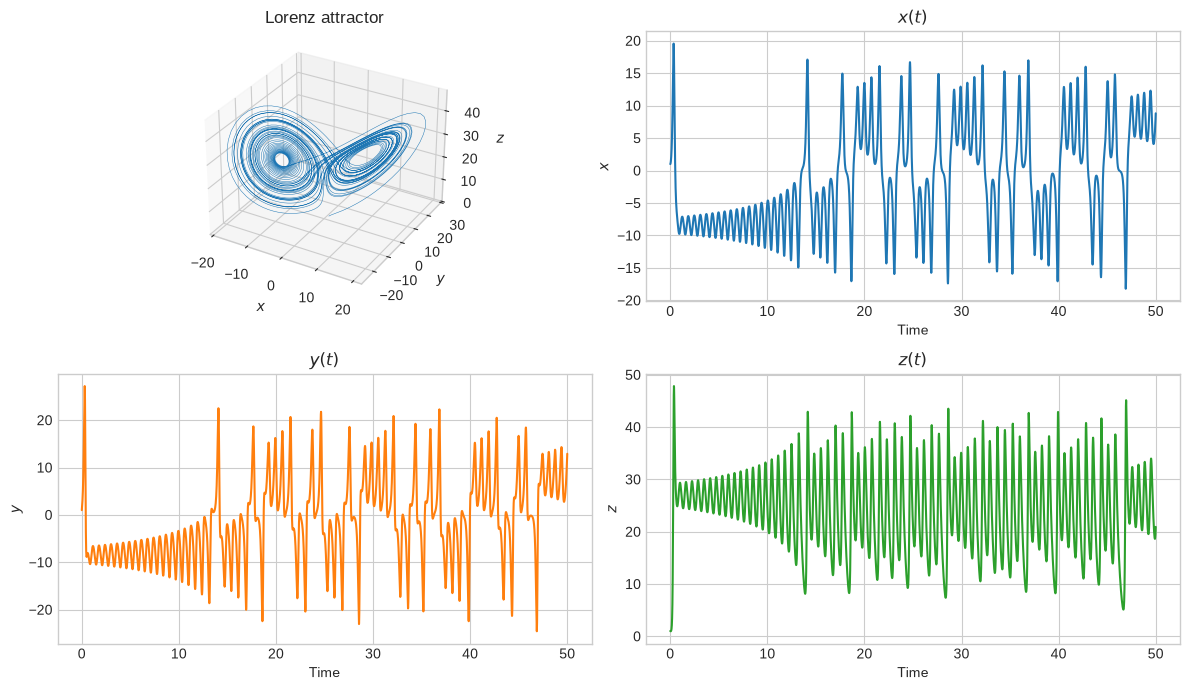

In [5]:
def lorenz_rhs(state, parameters):
    x, y, z = state
    sigma, rho, beta = parameters
    return sigma * (y - x), x * (rho - z) - y, x * y - beta * z


lorenz_parameters = (10.0, 28.0, 8.0 / 3.0)
t_lorenz, lorenz = rk4(lorenz_rhs, (1.0, 1.0, 1.0), 0.01, 50.0, lorenz_parameters)

fig = plt.figure(figsize=(12, 7))
ax3d = fig.add_subplot(2, 2, 1, projection="3d")
ax3d.plot(*lorenz.T, lw=0.35, color="tab:blue")
ax3d.set(title="Lorenz attractor", xlabel="$x$", ylabel="$y$", zlabel="$z$")
for i, (name, color) in enumerate(zip("xyz", ["tab:blue", "tab:orange", "tab:green"]), start=2):
    ax = fig.add_subplot(2, 2, i)
    ax.plot(t_lorenz, lorenz[:, i - 2], color=color)
    ax.set(title=f"${name}(t)$", xlabel="Time", ylabel=f"${name}$")
fig.tight_layout()
plt.show()

The line stays inside a butterfly-shaped region but switches between its two sides at irregular times. The changes of side can also be seen when $x(t)$ and $y(t)$ change sign.

### B.2 Rössler system

$$\dot{x}=-y-z,\qquad \dot{y}=x+ay,\qquad \dot{z}=b+z(x-c)$$

| Setting | Value |
|---|---|
| Parameters | $a=0.2$, $b=0.2$, $c=5.7$ |
| Initial condition | $(1,1,1)$ |
| Step and length | $dt=0.01$, $T=250$ (25,000 steps) |
| Solver | Fixed-step classical RK4 |

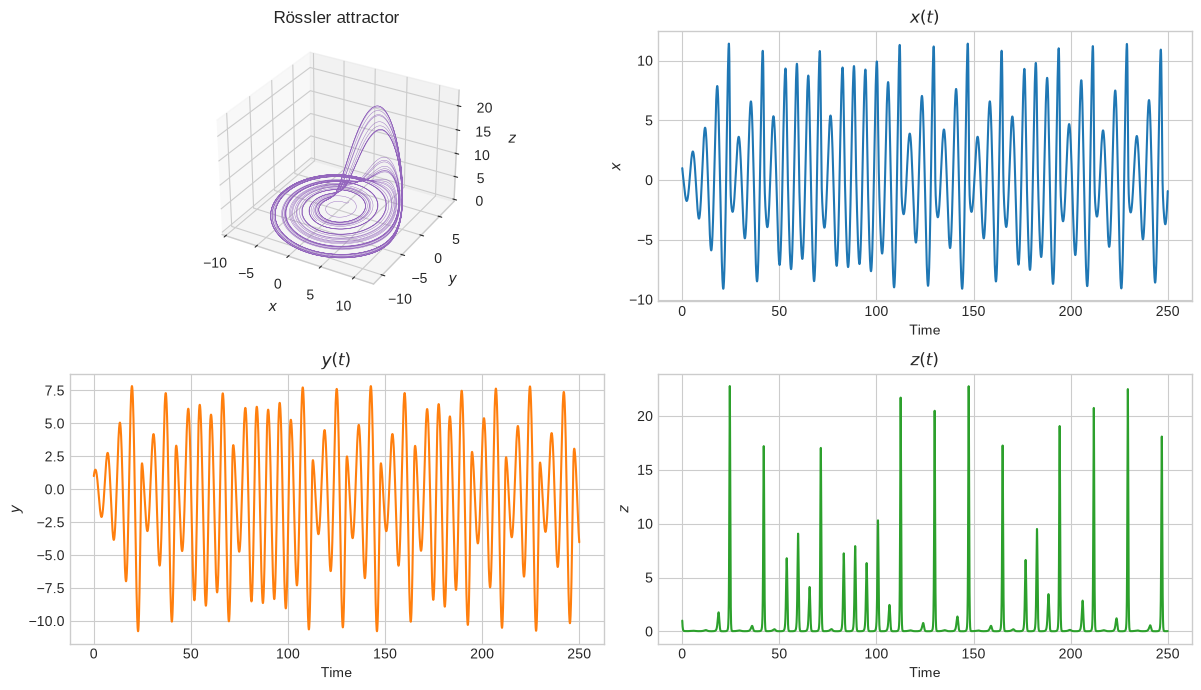

In [6]:
def rossler_rhs(state, parameters):
    x, y, z = state
    a, b, c = parameters
    return -y - z, x + a * y, b + z * (x - c)


rossler_parameters = (0.2, 0.2, 5.7)
t_rossler, rossler = rk4(rossler_rhs, (1.0, 1.0, 1.0), 0.01, 250.0, rossler_parameters)

fig = plt.figure(figsize=(12, 7))
ax3d = fig.add_subplot(2, 2, 1, projection="3d")
ax3d.plot(*rossler.T, lw=0.3, color="tab:purple")
ax3d.set(title="Rössler attractor", xlabel="$x$", ylabel="$y$", zlabel="$z$")
for i, (name, color) in enumerate(zip("xyz", ["tab:blue", "tab:orange", "tab:green"]), start=2):
    ax = fig.add_subplot(2, 2, i)
    ax.plot(t_rossler, rossler[:, i - 2], color=color)
    ax.set(title=f"${name}(t)$", xlabel="Time", ylabel=f"${name}$")
fig.tight_layout()
plt.show()

The line mostly spirals around one region, then makes a larger turn and folds back. The changing loop sizes and uneven peaks in $z(t)$ show that the motion is not simply periodic.

### B.3 Chen system

$$\dot{x}=a(y-x),\qquad \dot{y}=(c-a)x-xz+cy,\qquad \dot{z}=xy-bz$$

| Setting | Value |
|---|---|
| Parameters | $a=35$, $b=3$, $c=28$ |
| Initial condition | $(-0.1,0.5,-0.6)$ |
| Step and length | $dt=0.002$, $T=50$ (25,000 steps) |
| Solver | Fixed-step classical RK4 |

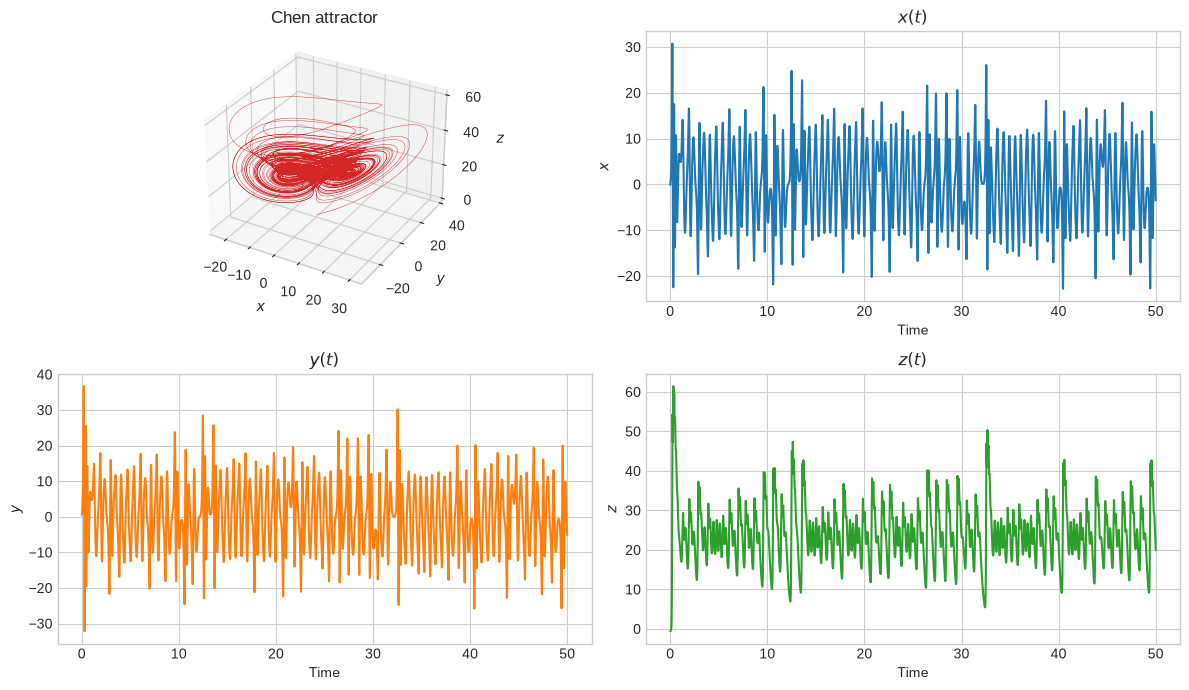

In [7]:
def chen_rhs(state, parameters):
    x, y, z = state
    a, b, c = parameters
    return a * (y - x), (c - a) * x - x * z + c * y, x * y - b * z


chen_parameters = (35.0, 3.0, 28.0)
t_chen, chen = rk4(chen_rhs, (-0.1, 0.5, -0.6), 0.002, 50.0, chen_parameters)

fig = plt.figure(figsize=(12, 7))
ax3d = fig.add_subplot(2, 2, 1, projection="3d")
ax3d.plot(*chen.T, lw=0.3, color="tab:red")
ax3d.set(title="Chen attractor", xlabel="$x$", ylabel="$y$", zlabel="$z$")
for i, (name, color) in enumerate(zip("xyz", ["tab:blue", "tab:orange", "tab:green"]), start=2):
    ax = fig.add_subplot(2, 2, i)
    ax.plot(t_chen, chen[:, i - 2], color=color)
    ax.set(title=f"${name}(t)$", xlabel="Time", ylabel=f"${name}$")
fig.tight_layout()
plt.show()

The Chen system also makes a two-sided shape, but it is different from the Lorenz butterfly. Its values remain limited yet do not repeat, showing chaotic switching between the two sides.

### B.4 Hyperchaotic Rössler system

$$\dot{x}=-y-z,\quad \dot{y}=x+ay+w,\quad \dot{z}=b+xz,\quad \dot{w}=-cz+dw$$

| Setting | Value |
|---|---|
| Parameters | $a=0.25$, $b=3$, $c=0.5$, $d=0.05$ |
| Initial condition | $(-10,-6,0,10)$ |
| Step and length | $dt=0.01$, $T=250$ (25,000 steps) |
| Solver | Fixed-step classical RK4 |

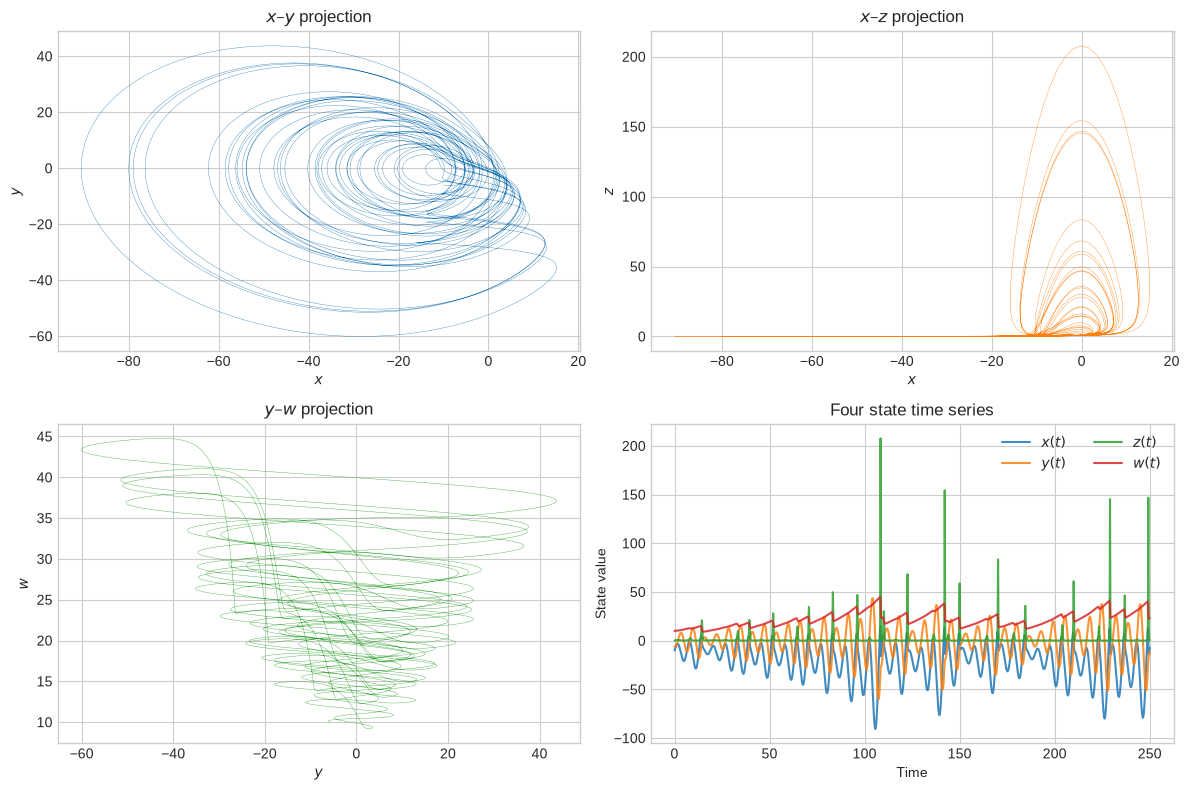

In [8]:
def hyper_rossler_rhs(state, parameters):
    x, y, z, w = state
    a, b, c, d = parameters
    return -y - z, x + a * y + w, b + x * z, -c * z + d * w


hyper_parameters = (0.25, 3.0, 0.5, 0.05)
t_hyper, hyper = rk4(hyper_rossler_rhs, (-10.0, -6.0, 0.0, 10.0), 0.01, 250.0, hyper_parameters)

fig = plt.figure(figsize=(12, 8))
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(hyper[:, 0], hyper[:, 1], lw=0.25)
ax1.set(title="$x$–$y$ projection", xlabel="$x$", ylabel="$y$")
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(hyper[:, 0], hyper[:, 2], lw=0.25, color="tab:orange")
ax2.set(title="$x$–$z$ projection", xlabel="$x$", ylabel="$z$")
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(hyper[:, 1], hyper[:, 3], lw=0.25, color="tab:green")
ax3.set(title="$y$–$w$ projection", xlabel="$y$", ylabel="$w$")
ax4 = fig.add_subplot(2, 2, 4)
for i, name in enumerate("xyzw"):
    ax4.plot(t_hyper, hyper[:, i], label=f"${name}(t)$", alpha=0.85)
ax4.set(title="Four state time series", xlabel="Time", ylabel="State value")
ax4.legend(ncol=2)
fig.tight_layout()
plt.show()

A four-dimensional shape cannot be shown directly, so the plots display it from three different two-dimensional views. Each view shows a different part of the bounded motion, which is more complex than the ordinary three-dimensional Rössler system.

## Part C — Sensitivity Analysis

### C.1 Lorenz $\rho$ sweep

Here $\rho$ is tested from 0 to 30 in steps of 0.2, while the other settings remain fixed. The first 30 time units are skipped, then the peaks of $z(t)$ are plotted to show the long-term behavior. If there is no peak, the final steady value is plotted once.

| Setting | Value |
|---|---|
| Swept parameter | $\rho \in [0,30]$, $\Delta\rho=0.2$; $\sigma=10$, $\beta=8/3$ fixed |
| Initial condition | $(1,1,1)$ |
| Integration | RK4, $dt=0.01$, $T=80$; discard the first 30 time units |
| Recorded quantity | Local maxima of retained $z(t)$; final equilibrium value only if no maximum exists |

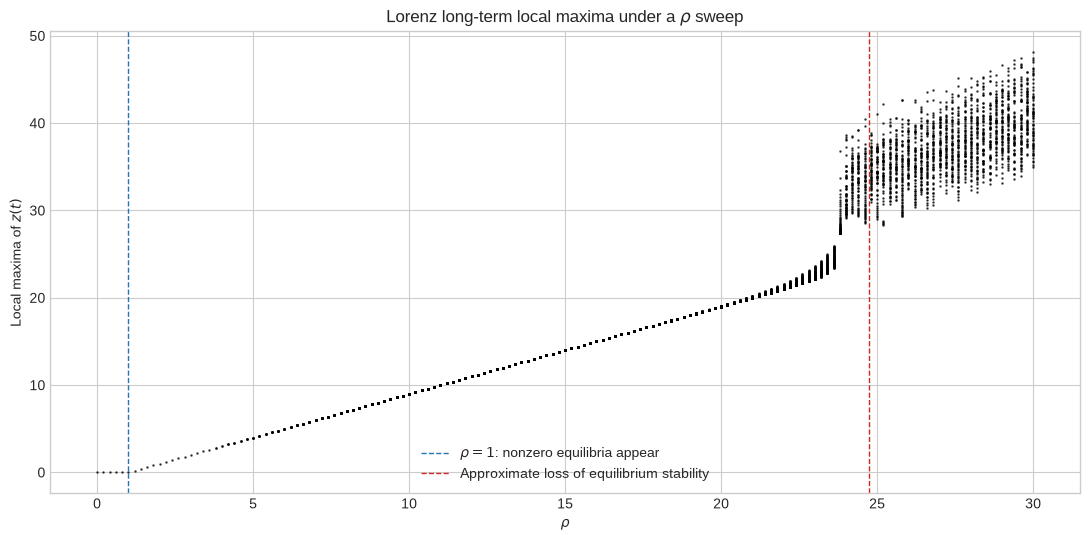

In [9]:
rho_values = np.arange(0.0, 30.0001, 0.2)
dt_sweep = 0.01
steps_sweep = int(80.0 / dt_sweep)
transient_steps = int(30.0 / dt_sweep)
states = np.tile(np.array([1.0, 1.0, 1.0]), (len(rho_values), 1))


def lorenz_sweep_rhs(batch):
    x, y, z = batch.T
    return np.column_stack((10.0 * (y - x), x * (rho_values - z) - y, x * y - (8.0 / 3.0) * z))


retained_z = np.empty((steps_sweep - transient_steps + 1, len(rho_values)))
save_index = 0
for step in range(steps_sweep + 1):
    if step >= transient_steps:
        retained_z[save_index] = states[:, 2]
        save_index += 1
    if step == steps_sweep:
        break
    k1 = lorenz_sweep_rhs(states)
    k2 = lorenz_sweep_rhs(states + 0.5 * dt_sweep * k1)
    k3 = lorenz_sweep_rhs(states + 0.5 * dt_sweep * k2)
    k4 = lorenz_sweep_rhs(states + dt_sweep * k3)
    states += (dt_sweep / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

rho_points, maxima_points = [], []
for j, rho in enumerate(rho_values):
    z = retained_z[:, j]
    maxima = z[1:-1][(z[1:-1] > z[:-2]) & (z[1:-1] >= z[2:])]
    if len(maxima) == 0:
        maxima = np.array([z[-1]])
    rho_points.extend(np.full(len(maxima), rho))
    maxima_points.extend(maxima)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.scatter(rho_points, maxima_points, s=0.7, color="black", alpha=0.65, rasterized=True)
ax.axvline(1.0, color="tab:blue", ls="--", lw=1, label="$\\rho=1$: nonzero equilibria appear")
ax.axvline(24.74, color="tab:red", ls="--", lw=1, label="Approximate loss of equilibrium stability")
ax.set(title="Lorenz long-term local maxima under a $\\rho$ sweep", xlabel="$\\rho$", ylabel="Local maxima of $z(t)$")
ax.legend()
fig.tight_layout()
plt.show()

For $\rho<1$, the values move toward zero; above $\rho=1$, they settle at a nonzero steady value. Near $\rho\approx24.74$, the peaks spread into irregular bands, showing the start of chaos.

### C.2 Step-size sensitivity

The Lorenz system is now run with three step sizes: $dt=0.001$, $0.01$, and $0.05$. Everything else stays the same, and the results are placed on the $dt=0.01$ time grid so they can be compared at the same times.

| Setting | Value |
|---|---|
| Step sizes | $dt=0.001$ (fine), $0.01$ (baseline), $0.05$ (coarse) |
| Fixed parameters | $\sigma=10$, $\rho=28$, $\beta=8/3$ |
| Initial condition and length | $(1,1,1)$; $T=50$ |
| Solver and comparison grid | Fixed-step RK4; interpolation onto the $dt=0.01$ baseline grid for pointwise differences |

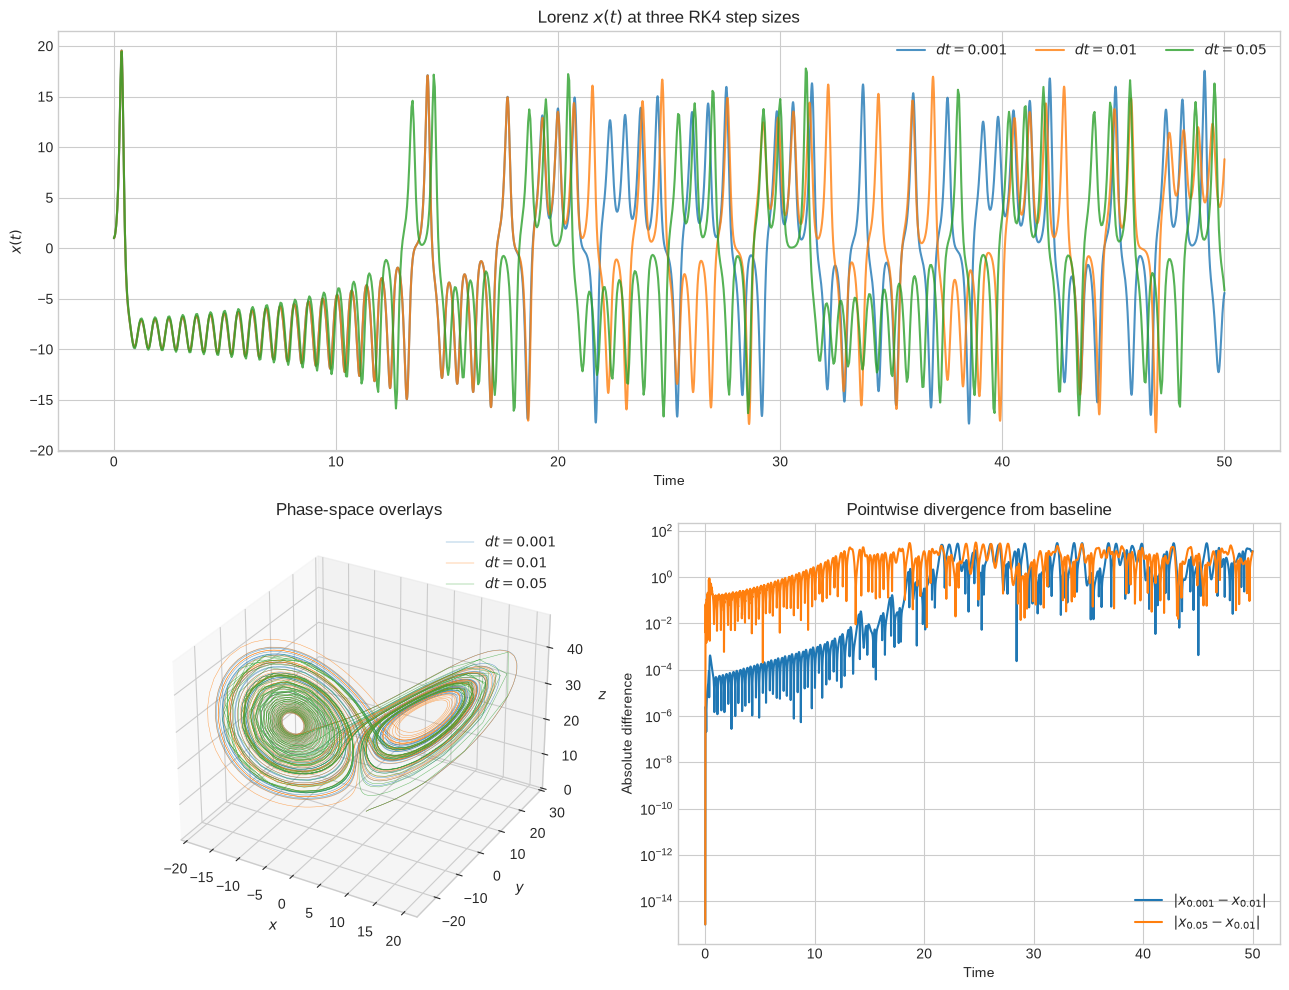

In [10]:
step_sizes = (0.001, 0.01, 0.05)
solutions = {
    dt: rk4(lorenz_rhs, (1.0, 1.0, 1.0), dt, 50.0, lorenz_parameters)
    for dt in step_sizes
}

t_base, y_base = solutions[0.01]
fine_x = np.interp(t_base, solutions[0.001][0], solutions[0.001][1][:, 0])
coarse_x = np.interp(t_base, solutions[0.05][0], solutions[0.05][1][:, 0])

fig = plt.figure(figsize=(13, 10))
ax1 = fig.add_subplot(2, 1, 1)
for dt, (t, y) in solutions.items():
    ax1.plot(t, y[:, 0], label=f"$dt={dt}$", alpha=0.8)
ax1.set(title="Lorenz $x(t)$ at three RK4 step sizes", xlabel="Time", ylabel="$x(t)$")
ax1.legend(ncol=3)

ax2 = fig.add_subplot(2, 2, 3, projection="3d")
for dt, (_, y) in solutions.items():
    ax2.plot(*y.T, lw=0.35, label=f"$dt={dt}$", alpha=0.7)
ax2.set(title="Phase-space overlays", xlabel="$x$", ylabel="$y$", zlabel="$z$")
ax2.legend()

ax3 = fig.add_subplot(2, 2, 4)
ax3.semilogy(t_base, np.maximum(np.abs(fine_x - y_base[:, 0]), 1e-15), label="$|x_{0.001}-x_{0.01}|$")
ax3.semilogy(t_base, np.maximum(np.abs(coarse_x - y_base[:, 0]), 1e-15), label="$|x_{0.05}-x_{0.01}|$")
ax3.set(title="Pointwise divergence from baseline", xlabel="Time", ylabel="Absolute difference")
ax3.legend()
fig.tight_layout()
plt.show()

Tiny calculation differences grow quickly because the Lorenz system is very sensitive, so the lines eventually separate. The $dt=0.001$ and $dt=0.01$ results are closest, while $dt=0.05$ separates earlier. Therefore, $dt=0.01$ is suitable here.

## What I Observed

From my results, discrete maps update step by step and show chaos through branch splitting in bifurcation diagrams, while continuous systems evolve with time and form bounded attractors in phase space. Ordinary chaotic systems separate nearby paths mainly in one direction, but the hyperchaotic Rössler system separates them in at least two directions, making its four-state motion more complex. Both types are sensitive to small changes, as the Lorenz step-size comparison showed.